In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

#DATA PREPARATION
url_data = 'https://raw.githubusercontent.com/137Leo/DDM_Project/refs/heads/main/kc_house_data.csv'
df = pd.read_csv(url_data)

url_income = 'https://raw.githubusercontent.com/137Leo/DDM_Project/refs/heads/main/King%20County_CensusZipCodeTabulationArea.csv'
url_bahnhoefe = 'https://github.com/137Leo/DDM_Project/raw/refs/heads/main/King_County_Train_Centers.xlsx'

bahnhoefe = pd.read_excel(url_bahnhoefe)
income = pd.read_csv(url_income)

DATA PREPARATION - Import der verwendeteten libraries und einlesen der Daten aus den github Pfaden.


In [19]:
url_data = 'https://raw.githubusercontent.com/137Leo/DDM_Project/refs/heads/main/kc_house_data.csv'
df = pd.read_csv(url_data)

url_income = 'https://raw.githubusercontent.com/137Leo/DDM_Project/refs/heads/main/King%20County_CensusZipCodeTabulationArea.csv'
url_bahnhoefe = 'https://github.com/137Leo/DDM_Project/raw/refs/heads/main/King_County_Train_Centers.xlsx'

bahnhoefe = pd.read_excel(url_bahnhoefe)
income = pd.read_csv(url_income)

Zuweisung der Externen Daten zum Häuserdatensatz mit durch eigene definierte Funktionen.

Bahnhöfe: Berechnung der Distanz zwischen den ÖPNV-Knotenpunkten über "lat" und "long". Auswahl der minimalen Distanz -> Speichern des Wertes in "distance_transit"

Income: Join über die Postleihzahl -> Speichern des Wertes in "med_household_income"

In [20]:
def bahnhof_zuweisung():
    t_dist = 0
    for row in df.itertuples():
        t_dist = np.sqrt(np.square(bahnhoefe["LATITUDE"]-row.lat) + (np.square(bahnhoefe["LONGITUDE"]-row.long)))
        df.loc[row.Index, "distance_transit"] = t_dist.min()
      
def income_zuweisung(df, income):
    df = df.merge(income[["placeName", "Value:Median_Income_Household"]], left_on="zipcode", right_on="placeName", how="left")
    df = df.rename(columns={"Value:Median_Income_Household": "med_household_income"})
    return df


bahnhof_zuweisung()
df = income_zuweisung(df, income)

Normalisierung der Attribute "price", "sqft_living", "sqft_lot", "sqft_living15", "sqft_lot15".
Bereinigung des Ausreißers von 33 von "bedrooms" 

Erstellen der neuen Attribute "age" (Alter des Gebäudes), sowie "sqft_liv_ratio" und "sqft_lot_ratio" (Verhältnis zwischen der eigenen Wohnungs / Grundstücks-größe mit den Umliegenden Gebäuden)

In [21]:
df["price"] = np.log1p(df["price"])
df["sqft_living"] = np.log1p(df["sqft_living"])
df["sqft_lot"] = np.log1p(df["sqft_lot"])
df["sqft_living15"] = np.log1p(df["sqft_living15"])
df["sqft_lot15"] = np.log1p(df["sqft_lot15"])

df = df[df["bedrooms"] <= 10]
df["age"] = 2015 - df["yr_built"]
df["sqft_liv_ratio"] = df["sqft_living"]/df["sqft_living15"]
df["sqft_lot_ratio"] = df["sqft_lot"]/df["sqft_lot15"]

In [22]:
house_attributes = ["bedrooms", "bathrooms", "floors", "sqft_living", "sqft_lot", "sqft_liv_ratio", "sqft_lot_ratio",  "grade", "condition", "age"]

# Standardisieren damit alle Features gleich gewichtet sind
df[house_attributes] = StandardScaler().fit_transform(df[house_attributes])
X_scaled = df[house_attributes]

Bilden eines quality_scores zur Berücksichtigung der Hausattribute in einem Attribut

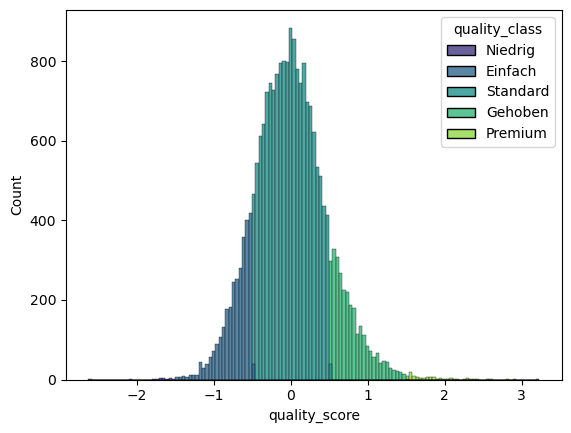

In [23]:
# Score = Durchschnitt der standardisierten Werte
df["quality_score"] = X_scaled.mean(axis=1)

#Qualitätsklasse zur visualisierung des quality_score features in einem Histogramm
df["quality_class"] = pd.cut(
    df["quality_score"],
    bins=[-float("inf"), -1.5, -0.5, 0.5, 1.5, float("inf")],
    labels=["Niedrig", "Einfach", "Standard", "Gehoben", "Premium"]
)

sns.histplot(data=df, x="quality_score", palette="viridis", hue="quality_class", alpha=0.8)
plt.show()

In [24]:
location_features = ["sqft_living15", "sqft_lot15", "view", "distance_transit", "med_household_income", "quality_score", "lat", "long"]
binary_features = ["waterfront"]

df[location_features] = StandardScaler().fit_transform(
    df[location_features]
)

#Datensatz in einer Excel speichern zur visuellen betrachtung
df.to_excel("Datensatz_Arjmandikia_Matavela_Bonitz.xlsx")

#Kombinieren der Location Features mit dem binären Feature "waterfront"
X = pd.concat([df[location_features], df[binary_features]], axis=1)

MODELING - Bestimmung der Anzahl an Clustern für KMeans mit Elbow-Methode und Sillhouette-Score

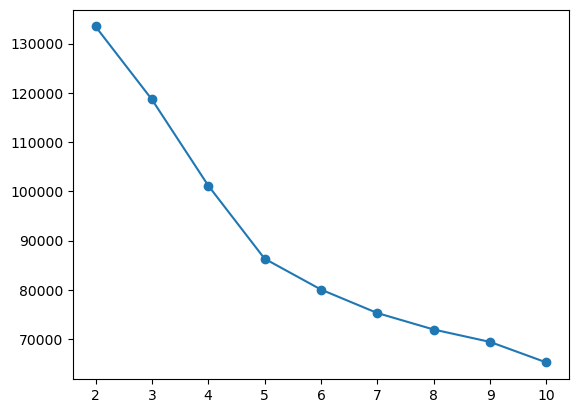

In [25]:
#Elbow-Methode
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(2, 11), inertias, marker="o")
plt.show()

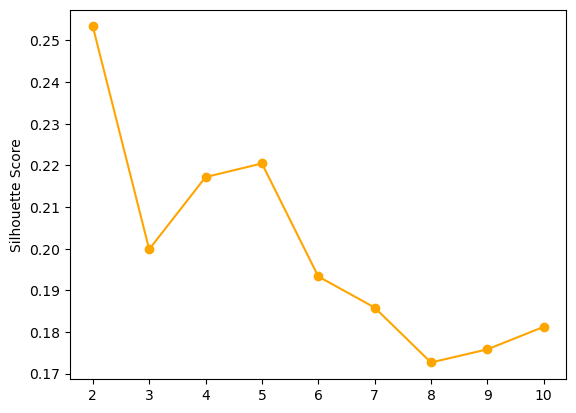

In [26]:
#Sillhouette Score
scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.plot(range(2, 11), scores, marker="o", color="orange")
plt.ylabel("Silhouette Score")
plt.show()

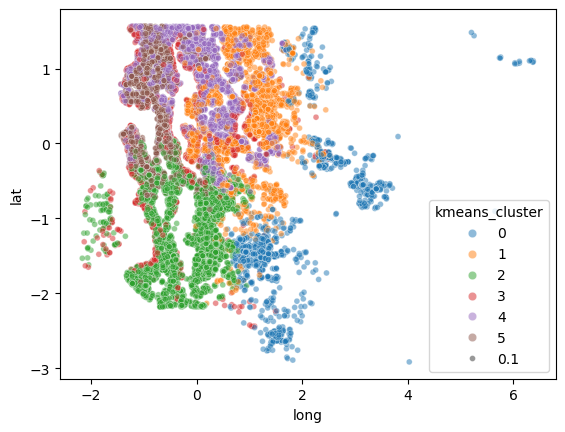

In [27]:
#KMEANS
kmeans = KMeans(n_clusters=6, random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(X)

sns.scatterplot(data=df, x="long", y="lat", hue="kmeans_cluster", palette="tab10", alpha=0.5, size=0.1)
plt.show()

Dimensionsreduzierung mit UMAP für DBSCAN und HDBSCAN

In [28]:
reducer = umap.UMAP(n_components=2, n_neighbors=30, random_state=42)
X_umap = reducer.fit_transform(X)

c:\Users\Leo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


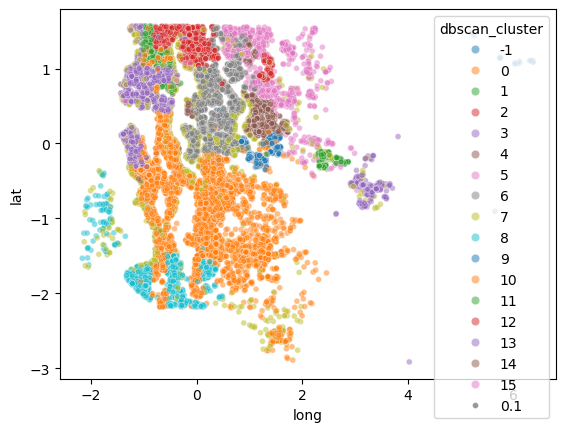

In [29]:
#DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=50)
df["dbscan_cluster"] = dbscan.fit_predict(X_umap)

sns.scatterplot(data=df, x="long", y="lat", hue="dbscan_cluster", palette="tab10", alpha=0.5, size=0.1)
plt.show()

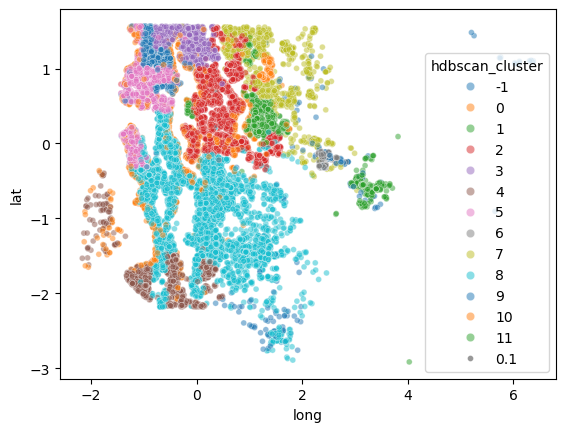

In [30]:
#HDBSCAN
hdbscan = HDBSCAN(min_cluster_size=200)
df["hdbscan_cluster"] = hdbscan.fit_predict(X_umap)

sns.scatterplot(data=df, x="long", y="lat", hue="hdbscan_cluster", palette="tab10", alpha=0.5, size=0.1)
plt.show()

EVALUATION - Betrachtung der Scores aller Clusterings -> Auswahl der HDSCAN-Cluster für nähere Betrachtung

In [31]:
print(silhouette_score(X, df["kmeans_cluster"]))
print(silhouette_score(X_umap, df["dbscan_cluster"]))
print(silhouette_score(X_umap,df["hdbscan_cluster"]))

print(davies_bouldin_score(X, df["kmeans_cluster"]))
print(davies_bouldin_score(X_umap, df["dbscan_cluster"]))
print(davies_bouldin_score(X_umap, df["hdbscan_cluster"]))

0.19333844528365907
0.2905382513999939
0.40718936920166016
1.4147008395827354
1.5310562501392841
1.195994411709741


Betrachtung einiger Verteilungen der Cluster-Attribute von HDBSCAN

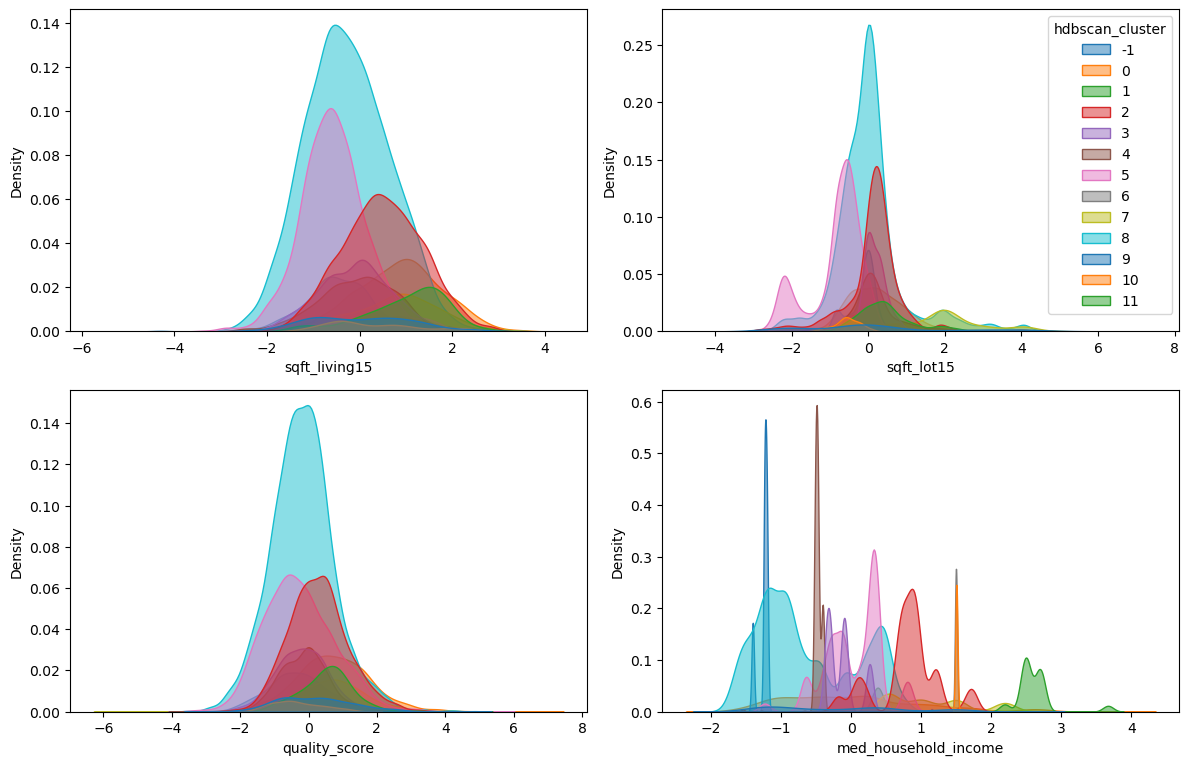

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.kdeplot(x=df["sqft_living15"], hue=df["hdbscan_cluster"], palette='tab10', ax=axes[0, 0], alpha=0.5, fill=True, legend=False)
sns.kdeplot(x=df["sqft_lot15"], hue=df["hdbscan_cluster"], palette='tab10', ax=axes[0, 1] ,alpha=0.5, fill=True, legend=True)
sns.kdeplot(x=df["quality_score"], hue=df["hdbscan_cluster"], palette='tab10', ax=axes[1, 0] ,alpha=0.5, fill=True, legend=False)
sns.kdeplot(x=df["med_household_income"], hue=df["hdbscan_cluster"], palette='tab10', ax=axes[1, 1] ,alpha=0.5, fill=True, legend=False)

plt.tight_layout()
plt.show()

Cluster- Werte werden in einer Excel gespeichert zur näheren Betrachtung.

In [ ]:
kmeans_info = df.groupby("kmeans_cluster")[location_features].agg(["mean"]).round(2)
dbscan_info = df.groupby("dbscan_cluster")[location_features].agg(["mean"]).round(2)
hdbscan_info = df.groupby("hdbscan_cluster")[location_features].agg(["mean"]).round(2)

with pd.ExcelWriter("Cluster_info.xlsx") as writer:
    kmeans_info.to_excel(writer, sheet_name="KMeans")
    dbscan_info.to_excel(writer, sheet_name="DBSCAN")
    hdbscan_info.to_excel(writer, sheet_name="HDBSCAN")